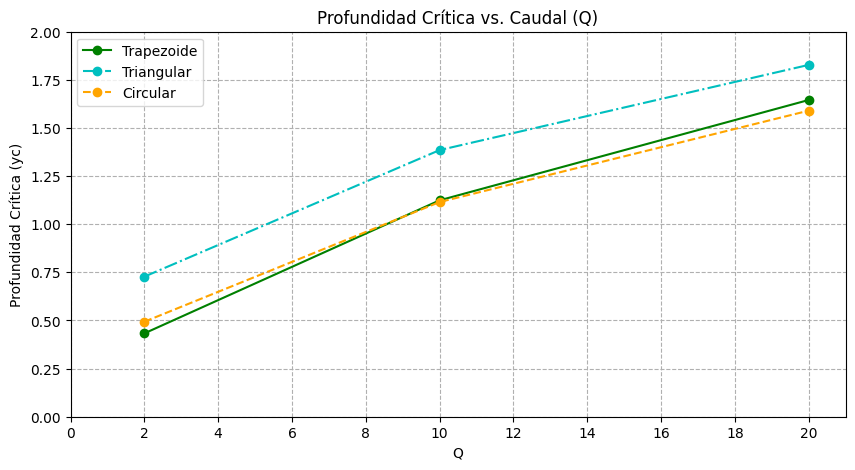

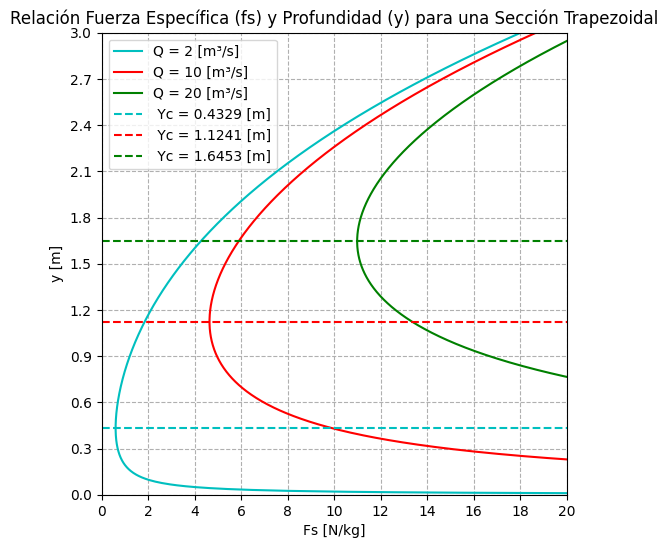

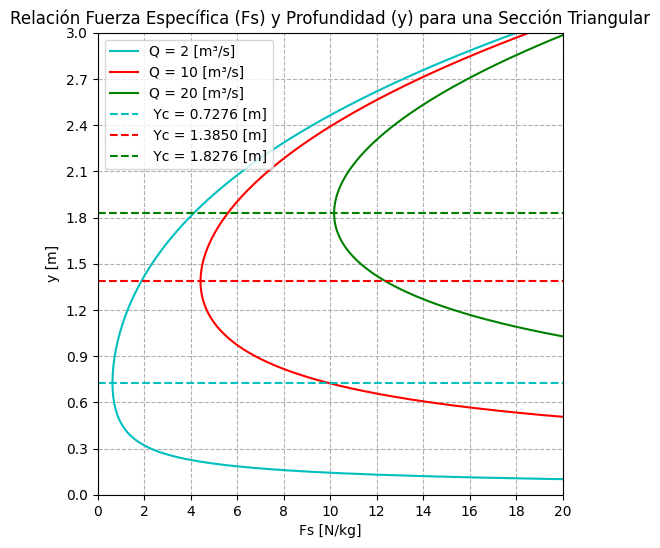

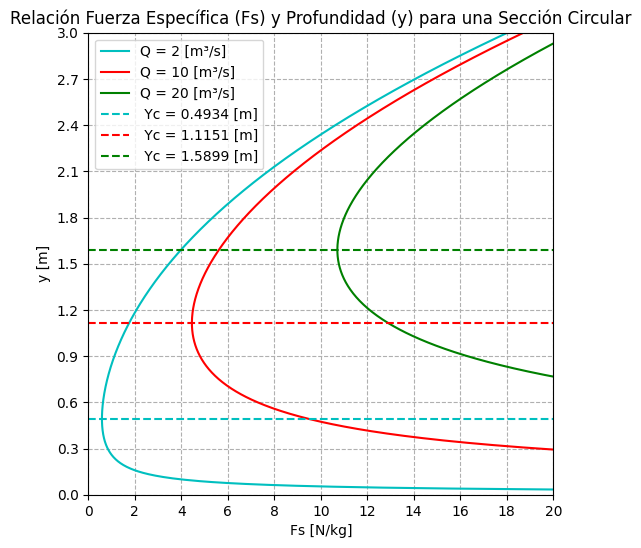

In [ ]:
import numpy as np
from numpy import sqrt
from numpy import sin
from numpy import cos
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

Q_array = np.array([2, 10, 20])
propiedades_figuras = np.array([[2,1,0],[0,2,0],[0,0,3]]) #(b,z,r)

def trapezoide(b,z,y):
  Width = b + 2*z*y
  area = (b + z*y)*y
  perimetro = b + 2*y*sqrt(1+z**2)
  D_hidraulica = ((b + z*y)*y)/(b + 2*z*y)
  centroide = ((b*y)*(y/2) + (1/3)*(z*y**3)) / area
  return area, perimetro, D_hidraulica, centroide, Width

def triangulo(z,y):
  Width = 2*z*y
  area = z*(y**2)
  perimetro = 2*y*sqrt(1+z**2)
  D_hidraulica = (1/2)*y
  centroide = (1/3)*y
  return area, perimetro, D_hidraulica, centroide, Width

def circulo(r,y):
  diametro = 2*r
  theta = np.arcsin((y - (diametro / 2)) / (diametro / 2)) * 2 + np.pi
  Width = 2*sqrt(y*(diametro-y))
  area = (1/8)*(theta-sin(theta))*(diametro**2)
  perimetro = (1/2)*theta*diametro
  D_hidraulica = (1/8)*((theta-sin(theta))/(sin(0.5*theta)))*diametro
  centroide = ((4*r*(sin(theta/2))**3)/(3*(theta - sin(theta)))) - r*cos(theta/2)
  return area, perimetro, D_hidraulica, centroide, Width

def yc_inicial(Q):
  #Asumimos que la sección es rectangular, de tal forma se obtiene un valor inicial para iterar
  b = 1
  return (Q**2/(9.81*b**2))**(1/3)

def yc(Q, A, D):
  return Q/sqrt(9.81) - A*sqrt(D)

def yc_trapezoide_derivada(Q,b,z,y):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A = trapezoide(b,z,y)[0]
  D = trapezoide(b,z,y)[2]
  A_aumento = trapezoide(b,z,y + h)[0]
  D_aumento = trapezoide(b,z,y + h)[2]
  return (yc(Q, A_aumento, D_aumento) - yc(Q, A, D)) / h

def yc_triangulo_derivada(Q,z,y):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A = triangulo(z,y)[0]
  D = triangulo(z,y)[2]
  A_aumento = triangulo(z,y + h)[0]
  D_aumento = triangulo(z,y + h)[2]
  return (yc(Q, A_aumento, D_aumento) - yc(Q, A, D)) / h


def yc_circulo_derivada(Q,r,y):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A = circulo(r,y)[0]
  D = circulo(r,y)[2]
  A_aumento = circulo(r,y + h)[0]
  D_aumento = circulo(r,y + h)[2]
  return (yc(Q, A_aumento, D_aumento) - yc(Q, A, D)) / h

def fuerza_especifica(Q, A, c):
  return  Q**2/(9.81*A) + c*A

def igualdad_fuerza_especifica(Q, A1, c1, A2, c2):
  return  Q**2/(9.81*A1) + c1*A1 - (Q**2/(9.81*A2) + c2*A2)


def profundidad_critica(Q_array, propiedades_figuras):
  yc_figuras = np.zeros((3, 3))
  t = 1e-6

  for i in range(len(Q_array)):
    Q = Q_array[i]
    y = yc_inicial(Q)

    #Trapezoide
    b = propiedades_figuras[0][0]
    z = propiedades_figuras[0][1]
    A = trapezoide(b,z,y)[0]
    D = trapezoide(b,z,y)[2]
    h = yc(Q, A, D) / yc_trapezoide_derivada(Q, b,z,y)

    while abs(h) >= 1e-6:
      A = trapezoide(b,z,y)[0]
      D = trapezoide(b,z,y)[2]
      h = yc(Q, A, D) / yc_trapezoide_derivada(Q, b,z,y)
      y = y - h

    yc_figuras[i][0] = y

    #Triangulo
    z = propiedades_figuras[1][1]
    A = triangulo(z,y)[0]
    D = triangulo(z,y)[2]
    h = yc(Q, A, D) / yc_triangulo_derivada(Q,z,y)

    while abs(h) >= 1e-6:
      A = triangulo(z,y)[0]
      D = triangulo(z,y)[2]
      h = yc(Q, A, D) / yc_triangulo_derivada(Q,z,y)
      y = y - h

    yc_figuras[i][1] = y

   #Circulo
    r = propiedades_figuras[2][2]
    A = circulo(r,y)[0]
    D = circulo(r,y)[2]
    h = yc(Q, A, D) / yc_circulo_derivada(Q,r,y)

    while abs(h) >= 1e-6:
      A = circulo(r,y)[0]
      D = circulo(r,y)[2]
      h = yc(Q, A, D) / yc_circulo_derivada(Q,r,y)
      y = y - h

    yc_figuras[i][2] = y

  return yc_figuras


def grafico_profundidad_critica(Q_array, propiedades_figuras):
  yc = profundidad_critica(Q_array, propiedades_figuras)

  y1 = yc[:, 0]
  y2 = yc[:, 1]
  y3 = yc[:, 2]

  plt.figure(figsize=(10, 5))

  plt.plot(Q_array, y1, color='green', marker='o', linestyle='-', label='Trapezoide')
  plt.plot(Q_array, y2, color='c', marker='o', linestyle='-.', label='Triangular')
  plt.plot(Q_array, y3, color='orange',  marker='o', linestyle='--', label='Circular')

  plt.xlabel('Q')
  plt.ylabel('Profundidad Crítica (yc)')
  plt.title('Profundidad Crítica vs. Caudal (Q)')
  plt.legend()
  plt.xlim(0, 21)
  plt.ylim(0, 2)
  max_Q = max(Q_array)
  plt.xticks(np.arange(0, max_Q + 2, 2))

  plt.grid(True, axis='both', linestyle='--')
  plt.show()

def grafico_momenta_Trapezoide(Q_array, propiedades_figuras):

  y = np.linspace(0.001, 3, 1000)
  A_trapezoide = np.zeros((len(Q_array)))
  c_trapezoide = np.zeros((len(Q_array)))
  fs = np.zeros((len(Q_array), 1000))

  for i in range(len(Q_array)):
    Q = Q_array[i]
    b = propiedades_figuras[0][0]
    z = propiedades_figuras[0][1]
    A_trapezoide = trapezoide(b, z, y)[0]
    c_trapezoide = trapezoide(b, z, y)[3]

    fs[i, :] = fuerza_especifica(Q, A_trapezoide, c_trapezoide)


  plt.figure(figsize=(6, 6))

  plt.plot(fs[0], y, color='c', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(fs[1], y, color='red', linestyle='-', label='Q = 10 [m³/s]')
  plt.plot(fs[2], y, color='green', linestyle='-', label='Q = 20 [m³/s]')

  y_c_0 = profundidad_critica(Q_array, propiedades_figuras)[0][0]
  plt.axhline(y=y_c_0, color='c', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_0:.4f} [m]')

  y_c_1 = profundidad_critica(Q_array, propiedades_figuras)[1][0]
  plt.axhline(y=y_c_1, color='red', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_1:.4f} [m]')

  y_c_2 = profundidad_critica(Q_array, propiedades_figuras)[2][0]
  plt.axhline(y=y_c_2, color='green', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_2:.4f} [m]')

  ax = plt.gca()
  ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
  ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

  plt.xlim(0, 20)
  plt.ylim(0, 3)
  plt.xlabel('Fs [N/kg]')
  plt.ylabel('y [m]')
  plt.title('Relación Fuerza Específica (fs) y Profundidad (y) para una Sección Trapezoidal')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')
  plt.show()

def grafico_momenta_triangulo(Q_array, propiedades_figuras):

  y = np.linspace(0.001, 3, 1000)
  A_trapezoide = np.zeros((len(Q_array)))
  c_trapezoide = np.zeros((len(Q_array)))
  fs = np.zeros((len(Q_array), 1000))

  for i in range(len(Q_array)):
    Q = Q_array[i]
    z = propiedades_figuras[1][1]
    A_triangulo = triangulo(z, y)[0]
    c_triangulo = triangulo(z, y)[3]

    fs[i, :] = fuerza_especifica(Q, A_triangulo, c_triangulo)

  plt.figure(figsize=(6, 6))

  plt.plot(fs[0], y, color='c', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(fs[1], y, color='red', linestyle='-', label='Q = 10 [m³/s]')
  plt.plot(fs[2], y, color='green', linestyle='-', label='Q = 20 [m³/s]')

  y_c_0 = profundidad_critica(Q_array, propiedades_figuras)[0][1]
  plt.axhline(y=y_c_0, color='c', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_0:.4f} [m]')

  y_c_1 = profundidad_critica(Q_array, propiedades_figuras)[1][1]
  plt.axhline(y=y_c_1, color='red', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_1:.4f} [m]')

  y_c_2 = profundidad_critica(Q_array, propiedades_figuras)[2][1]
  plt.axhline(y=y_c_2, color='green', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_2:.4f} [m]')

  ax = plt.gca()
  ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
  ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

  plt.xlim(0, 20)
  plt.ylim(0, 3)
  plt.xlabel('Fs [N/kg]')
  plt.ylabel('y [m]')
  plt.title('Relación Fuerza Específica (Fs) y Profundidad (y) para una Sección Triangular')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')
  plt.show()

def grafico_momenta_circulo(Q_array, propiedades_figuras):

  y = np.linspace(0.001, 3, 1000)
  A_trapezoide = np.zeros((len(Q_array)))
  c_trapezoide = np.zeros((len(Q_array)))
  fs = np.zeros((len(Q_array), 1000))

  for i in range(len(Q_array)):
    Q = Q_array[i]
    r = propiedades_figuras[2][2]
    A_circulo = circulo(r, y)[0]
    c_circulo = circulo(r, y)[3]

    fs[i, :] = fuerza_especifica(Q, A_circulo, c_circulo)

  plt.figure(figsize=(6, 6))

  plt.plot(fs[0], y, color='c', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(fs[1], y, color='red', linestyle='-', label='Q = 10 [m³/s]')
  plt.plot(fs[2], y, color='green', linestyle='-', label='Q = 20 [m³/s]')

  y_c_0 = profundidad_critica(Q_array, propiedades_figuras)[0][2]
  plt.axhline(y=y_c_0, color='c', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_0:.4f} [m]')

  y_c_1 = profundidad_critica(Q_array, propiedades_figuras)[1][2]
  plt.axhline(y=y_c_1, color='red', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_1:.4f} [m]')

  y_c_2 = profundidad_critica(Q_array, propiedades_figuras)[2][2]
  plt.axhline(y=y_c_2, color='green', linestyle='--', linewidth=1.5, label=f' Yc = {y_c_2:.4f} [m]')

  ax = plt.gca()
  ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
  ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

  plt.xlim(0, 20)
  plt.ylim(0, 3)
  plt.xlabel('Fs [N/kg]')
  plt.ylabel('y [m]')
  plt.title('Relación Fuerza Específica (Fs) y Profundidad (y) para una Sección Circular')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')
  plt.show()


#print(profundidad_critica(Q_array, propiedades_figuras))
grafico_profundidad_critica(Q_array, propiedades_figuras)
grafico_momenta_Trapezoide(Q_array, propiedades_figuras)
grafico_momenta_triangulo(Q_array, propiedades_figuras)
grafico_momenta_circulo(Q_array, propiedades_figuras)



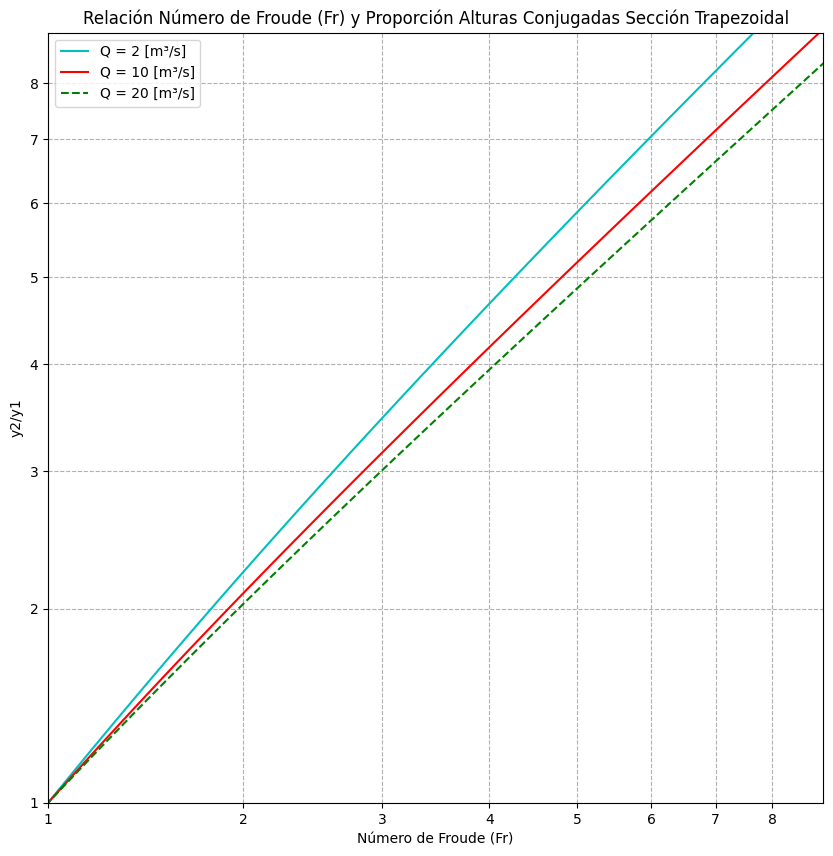

 Fr(Q = 2)  y2/y1 (Q = 2)  Fr(Q = 10)  y2/y1 (Q = 10)  Fr(Q = 20)  y2/y1 (Q = 20)
  9.841876      11.528520   49.209380       44.154777   98.418760       74.537384
  9.357311      10.970347   42.340502       38.431012   78.854722       60.924821
  8.910741      10.454608   36.915692       33.855469   64.946368       51.057548
  8.498130       9.976897   32.543644       30.127038   54.646107       43.624592
  8.115977       9.533385   28.959496       27.039510   46.769403       37.853801
  7.761229       9.120722   25.978255       24.447313   40.588440       33.263157
  7.431218       8.735973   23.467220       22.244993   35.633978       29.537445
  7.123600       8.376554   21.328992       20.354444   31.591344       26.462542
  6.836307       8.040179   19.490640       18.716683   28.242473       23.888311
  6.567514       7.724823   17.896589       17.286408   25.431994       21.706617
  6.315597       7.428686   16.503829       16.028297   23.046532       19.837758
  6.079114      

In [ ]:
#Profundidades conjugadas Trapezoidal

def igualdad_fuerza_especifica(Q, A1, c1, A2, c2):
  return  Q**2/(9.81*A1) + c1*A1 - (Q**2/(9.81*A2) + c2*A2)

def froude(Q, Width, A):
  return sqrt((Width*(Q**2))/(9.81*(A**3)))

def igualdad_fs_trapecio_derivada(Q,b,z,y1,y2):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A1 = trapezoide(b,z,y1)[0]
  c1 = trapezoide(b,z,y1)[3]

  A2 = trapezoide(b,z,y2)[0]
  c2 = trapezoide(b,z,y2)[3]
  A2_aumento = trapezoide(b,z,y2 + h)[0]
  c2_aumento = trapezoide(b,z,y2 + h)[3]

  return (igualdad_fuerza_especifica(Q, A1, c1, A2_aumento, c2_aumento) - igualdad_fuerza_especifica(Q, A1, c1, A2, c2)) / h

def profundidad_conjungada_trapecio(Q_array, propiedades_figuras):
  y1_list = []
  y2_list = []
  relacion_profundidades_list = []
  froude_list = []

  for i in range(len(Q_array)):
    #Trapezoide
    yc = profundidad_critica(Q_array, propiedades_figuras)[i][0]
    y1_array = np.linspace(0.1, yc, 100)
    y2_array = np.zeros_like(y1_array)
    froude_array = np.zeros_like(y1_array)
    Q = Q_array[i]

    b = propiedades_figuras[0][0]
    z = propiedades_figuras[0][1]

    y1_list.append(y1_array)

    for i in range(len(y1_array)):
      y1 = y1_array[i]
      y2 = y1 + yc
      A1 = trapezoide(b,z,y1)[0]
      c1 = trapezoide(b,z,y1)[3]
      A2 = trapezoide(b,z,y2)[0]
      c2 = trapezoide(b,z,y2)[3]
      width = trapezoide(b,z,y1)[4]

      h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_trapecio_derivada(Q,b,z,y1,y2)

      while abs(h) >= 1e-6:
        A1 = trapezoide(b,z,y1)[0]
        c1 = trapezoide(b,z,y1)[3]
        A2 = trapezoide(b,z,y2)[0]
        c2 = trapezoide(b,z,y2)[3]
        h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_trapecio_derivada(Q,b,z,y1,y2)
        y2 = y2 - h

      y2_array[i] = y2
      froude_array[i] = froude(Q, width, A1)

    y2_list.append(y2_array)
    froude_list.append(froude_array)

  for i in range(len(Q_array)):
    relacion_profundidades = y2_list[i]/y1_list[i]
    relacion_profundidades_list.append(relacion_profundidades)

  plt.figure(figsize=(10, 10))

  plt.plot(froude_list[0], relacion_profundidades_list[0], color='c', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(froude_list[1], relacion_profundidades_list[1], color='red', linestyle='-',  label='Q = 10 [m³/s]')
  plt.plot(froude_list[2], relacion_profundidades_list[2], color='green',  linestyle='--', label='Q = 20 [m³/s]')


  plt.xlim(1, 9)  # Set x-axis limits from 0 to 15
  plt.ylim(1, 9)   # Set y-axis limits from 0 to 3

  plt.yscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  plt.xscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  ticksy = np.arange(1, 9, 1)
  ticksx = np.arange(1, 9, 1)
  labels_y = [str(i) for i in ticksy]
  labels_x = [str(i) for i in ticksx]
  plt.xlabel('Número de Froude (Fr)')
  plt.ylabel('y2/y1')
  plt.yticks(ticksy,labels_y)
  plt.xticks(ticksx, labels_x)

  plt.title('Relación Número de Froude (Fr) y Proporción Alturas Conjugadas Sección Trapezoidal')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')
  plt.show()

  data = {'Fr(Q = 2)': froude_list[0], 'y2/y1 (Q = 2)': relacion_profundidades_list[0], 'Fr(Q = 10)': froude_list[1], 'y2/y1 (Q = 10)': relacion_profundidades_list[1], 'Fr(Q = 20)': froude_list[2], 'y2/y1 (Q = 20)': relacion_profundidades_list[2]}
  tabla_comparativa = pd.DataFrame(data)
  with pd.option_context('display.max_rows', None, 'display.max_columns', None): print(tabla_comparativa.to_string(index=False))

  return

profundidad_conjungada_trapecio(Q_array, propiedades_figuras)


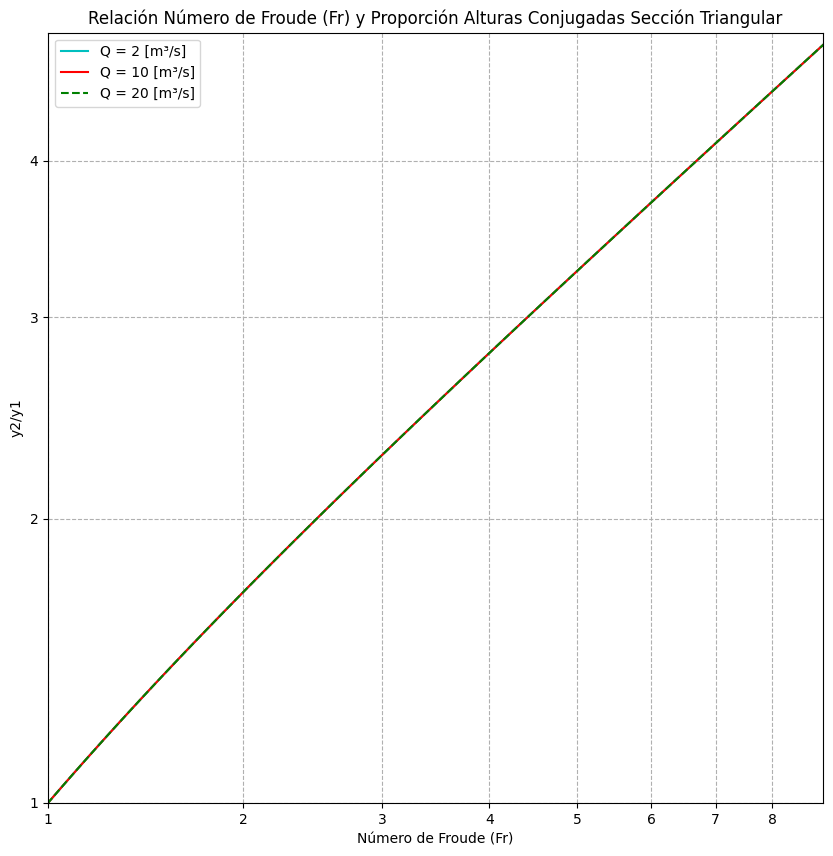

 Fr(Q = 2)  y2/y1 (Q = 2)  Fr(Q = 10)  y2/y1 (Q = 10)  Fr(Q = 20)  y2/y1 (Q = 20)
142.784312      31.261318  713.921561       91.435243 1427.843123      145.147845
122.447122      28.215471  526.193267       74.605059  955.095481      111.015420
105.945316      25.617659  400.928160       62.235476  675.536182       88.127422
 92.396752      23.381975  313.746670       52.848457  498.392714       71.953286
 81.155143      21.442427  250.962767       45.537409  380.043312       60.054608
 71.739003      19.747604  204.453455       39.719512  297.592730       51.018078
 63.784196      18.256939  169.171732       35.005327  238.167185       43.975609
 57.011578      16.938052  141.859319       31.126071  194.115600       38.368508
 51.204508      15.764826  120.343121       27.891062  160.678935       33.823109
 46.192960      14.715997  103.132636       25.161783  134.781951       30.081316
 41.842120      13.774100   89.180338       22.835513  114.371995       26.959901
 38.044076      

In [ ]:
#Profundidades conjugadas triangular

def igualdad_fuerza_especifica(Q, A1, c1, A2, c2):
  return  Q**2/(9.81*A1) + c1*A1 - (Q**2/(9.81*A2) + c2*A2)

def froude(Q, Width, A):
  return sqrt((Width*(Q**2))/(9.81*(A**3)))

def igualdad_fs_triangulo_derivada(Q,z,y1,y2):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A1 = triangulo(z,y1)[0]
  c1 = triangulo(z,y1)[3]

  A2 = triangulo(z,y2)[0]
  c2 = triangulo(z,y2)[3]
  A2_aumento = triangulo(z,y2 + h)[0]
  c2_aumento = triangulo(z,y2 + h)[3]
  return (igualdad_fuerza_especifica(Q, A1, c1, A2_aumento, c2_aumento) - igualdad_fuerza_especifica(Q, A1, c1, A2, c2)) / h

def profundidad_conjungada_triangulo(Q_array, propiedades_figuras):
  y1_list = []
  y2_list = []
  relacion_profundidades_list = []
  froude_list = []

  for i in range(len(Q_array)):
    #Triangular
    yc = profundidad_critica(Q_array, propiedades_figuras)[i][1]
    y1_array = np.linspace(0.1, yc, 100)
    y2_array = np.zeros_like(y1_array)
    froude_array = np.zeros_like(y1_array)
    Q = Q_array[i]

    z = propiedades_figuras[1][1]

    y1_list.append(y1_array)

    for i in range(len(y1_array)):
      y1 = y1_array[i]
      y2 = y1 + yc
      A1 = triangulo(z,y1)[0]
      c1 = triangulo(z,y1)[3]
      A2 = triangulo(z,y2)[0]
      c2 = triangulo(z,y2)[3]
      width = triangulo(z,y1)[4]

      h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_triangulo_derivada(Q,z,y1,y2)

      while abs(h) >= 1e-6:
        A1 = triangulo(z,y1)[0]
        c1 = triangulo(z,y1)[3]
        A2 = triangulo(z,y2)[0]
        c2 = triangulo(z,y2)[3]
        h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_triangulo_derivada(Q,z,y1,y2)
        y2 = y2 - h

      y2_array[i] = y2
      froude_array[i] = froude(Q, width, A1)

    y2_list.append(y2_array)
    froude_list.append(froude_array)

  for i in range(len(Q_array)):
    relacion_profundidades = y2_list[i]/y1_list[i]
    relacion_profundidades_list.append(relacion_profundidades)
  plt.figure(figsize=(10, 10))

  plt.plot(froude_list[0], relacion_profundidades_list[0], color='c', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(froude_list[1], relacion_profundidades_list[1], color='red', linestyle='-',  label='Q = 10 [m³/s]')
  plt.plot(froude_list[2], relacion_profundidades_list[2], color='green',  linestyle='--', label='Q = 20 [m³/s]')


  plt.xlim(1, 9)
  plt.ylim(1, 5)
  plt.yscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  plt.xscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  ticksy = np.arange(1, 5, 1)
  ticksx = np.arange(1, 9, 1)
  labels_y = [str(i) for i in ticksy]
  labels_x = [str(i) for i in ticksx]
  plt.xlabel('Número de Froude (Fr)')
  plt.ylabel('y2/y1')
  plt.yticks(ticksy,labels_y)
  plt.xticks(ticksx, labels_x)
  plt.xlabel('Número de Froude (Fr)')
  plt.ylabel('y2/y1')
  plt.title('Relación Número de Froude (Fr) y Proporción Alturas Conjugadas Sección Triangular')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')
  plt.show()

  data = {'Fr(Q = 2)': froude_list[0], 'y2/y1 (Q = 2)': relacion_profundidades_list[0], 'Fr(Q = 10)': froude_list[1], 'y2/y1 (Q = 10)': relacion_profundidades_list[1], 'Fr(Q = 20)': froude_list[2], 'y2/y1 (Q = 20)': relacion_profundidades_list[2]}
  tabla_comparativa = pd.DataFrame(data)
  with pd.option_context('display.max_rows', None, 'display.max_columns', None): print(tabla_comparativa.to_string(index=False))


profundidad_conjungada_triangulo(Q_array, propiedades_figuras)



<ipython-input-28-cf82504831e5>:31: RuntimeWarning: invalid value encountered in arcsin
  theta = np.arcsin((y - (diametro / 2)) / (diametro / 2)) * 2 + np.pi
<ipython-input-28-cf82504831e5>:32: RuntimeWarning: invalid value encountered in sqrt
  Width = 2*sqrt(y*(diametro-y))


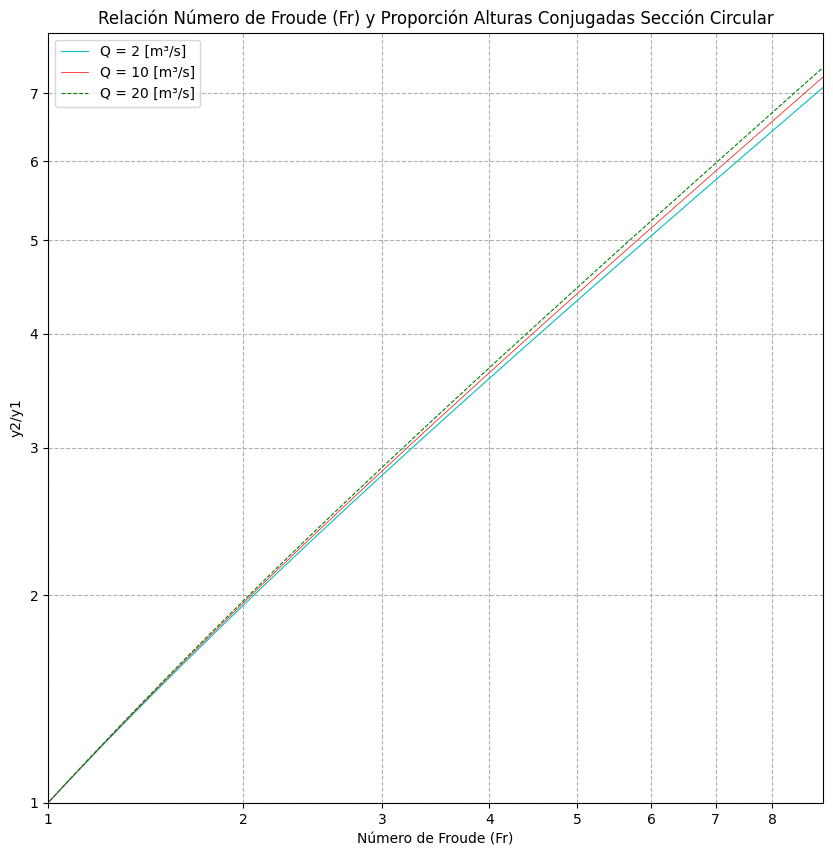

 Fr(Q = 2)  y2/y1 (Q = 2)  Fr(Q = 10)  y2/y1 (Q = 10)  Fr(Q = 20)  y2/y1 (Q = 20)
 24.025760      15.875616  120.128800             NaN  240.257601             NaN
 22.227259      14.898679   98.857877             NaN  181.603852             NaN
 20.623600      14.014736   82.779059             NaN  142.090301             NaN
 19.187614      13.211946   70.330053             NaN  114.210335             NaN
 17.896711      12.480328   60.494897             NaN   93.806895             NaN
 16.731978      11.811421   52.589753             NaN   78.426700             NaN
 15.677490      11.198005   46.140644             NaN   66.546098             NaN
 14.719755      10.633891   40.810654             NaN   57.178258             NaN
 13.847286      10.113745   36.354981             NaN   49.661215             NaN
 13.050250       9.632950   32.592279             NaN   43.537486             NaN
 12.320193       9.187491   29.385904             NaN   38.482701             NaN
 11.649813      

In [ ]:
#Profundidades conjugadas Circular

def igualdad_fuerza_especifica(Q, A1, c1, A2, c2):
  return  Q**2/(9.81*A1) + c1*A1 - (Q**2/(9.81*A2) + c2*A2)

def froude(Q, Width, A):
  return sqrt((Width*(Q**2))/(9.81*(A**3)))

def igualdad_fs_circulo_derivada(Q,r,y1,y2):
  #Derivada numérica para el método de Newton-Rhapson
  h=1e-6
  A1 = circulo(r,y1)[0]
  c1 = circulo(r,y1)[3]

  A2 = circulo(r,y2)[0]
  c2 = circulo(r,y2)[3]
  A2_aumento = circulo(r,y2 + h)[0]
  c2_aumento = circulo(r,y2 + h)[3]
  return (igualdad_fuerza_especifica(Q, A1, c1, A2_aumento, c2_aumento) - igualdad_fuerza_especifica(Q, A1, c1, A2, c2)) / h

def profundidad_conjungada_circulo(Q_array, propiedades_figuras):
  y1_list = []
  y2_list = []
  relacion_profundidades_list = []
  froude_list = []

  for i in range(len(Q_array)):
    #Trapezoide
    yc = profundidad_critica(Q_array, propiedades_figuras)[i][2]
    y1_array = np.linspace(0.1, yc , 100)
    y2_array = np.zeros_like(y1_array)
    froude_array = np.zeros_like(y1_array)
    Q = Q_array[i]

    r = propiedades_figuras[2][2]

    y1_list.append(y1_array)

    for i in range(len(y1_array)):
      y1 = y1_array[i]
      y2 = yc + y1
      A1 = circulo(r,y1)[0]
      c1 = circulo(r,y1)[3]
      A2 = circulo(r,y2)[0]
      c2 = circulo(r,y2)[3]
      width = circulo(r,y1)[4]

      h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_circulo_derivada(Q,r,y1,y2)

      while abs(h) >= 1e-6:
        A1 = circulo(r,y1)[0]
        c1 = circulo(r,y1)[3]
        A2 = circulo(r,y2)[0]
        c2 = circulo(r,y2)[3]
        h = igualdad_fuerza_especifica(Q, A1, c1, A2, c2) / igualdad_fs_circulo_derivada(Q,r,y1,y2)
        y2 = y2 - h

      y2_array[i] = y2
      froude_array[i] = froude(Q, width, A1)

    y2_list.append(y2_array)
    froude_list.append(froude_array)

  for i in range(len(Q_array)):
    relacion_profundidades = y2_list[i]/y1_list[i]
    relacion_profundidades_list.append(relacion_profundidades)

  plt.figure(figsize=(10, 10))

  plt.plot(froude_list[0], relacion_profundidades_list[0], color='c', linewidth='0.8', linestyle='-', label='Q = 2 [m³/s]')
  plt.plot(froude_list[1], relacion_profundidades_list[1], color='red', linewidth='0.5', linestyle='-',  label='Q = 10 [m³/s]')
  plt.plot(froude_list[2], relacion_profundidades_list[2], color='green', linewidth='0.8', linestyle='--', label='Q = 20 [m³/s]')


  plt.xlim(1, 9)
  plt.ylim(1, 8)
  plt.yscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  plt.xscale('function', functions=(lambda x: np.log(x + 1), lambda x: np.exp(x) - 1))
  ticksy = np.arange(1, 8, 1)
  ticksx = np.arange(1, 9, 1)
  labels_y = [str(i) for i in ticksy]
  labels_x = [str(i) for i in ticksx]
  plt.xlabel('Número de Froude (Fr)')
  plt.ylabel('y2/y1')
  plt.yticks(ticksy,labels_y)
  plt.xticks(ticksx, labels_x)
  plt.title('Relación Número de Froude (Fr) y Proporción Alturas Conjugadas Sección Circular')
  plt.legend()
  plt.grid(True, axis='both', linestyle='--')

  plt.show()

  data = {'Fr(Q = 2)': froude_list[0], 'y2/y1 (Q = 2)': relacion_profundidades_list[0], 'Fr(Q = 10)': froude_list[1], 'y2/y1 (Q = 10)': relacion_profundidades_list[1], 'Fr(Q = 20)': froude_list[2], 'y2/y1 (Q = 20)': relacion_profundidades_list[2]}
  tabla_comparativa = pd.DataFrame(data)
  with pd.option_context('display.max_rows', None, 'display.max_columns', None): print(tabla_comparativa.to_string(index=False))



profundidad_conjungada_circulo(Q_array, propiedades_figuras)
